# ORF307 Homework 4 {-}
Due: Friday, February 27th, 2026 9:00 pm ET

- The jupyter file is available on Canvas,
- Please export your code with output as `pdf`.
- If there is any additional answers, please combine them as **ONE** pdf file before submitting to the Gradescope.

# Q1 Fitting a line with different norms (30 pts) {-}

In [5]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog
# df = pd.read_csv('/content/drive/MyDrive/HW4Q1.csv')
df = pd.read_csv('HW4Q1.csv')
y = df['y'].values
t = df['t'].values

(a) (10 pts)*Least-squares:* select $\alpha$ and $\beta$ by minimizing $$\sum_{i=1}^{42} (y_i - \alpha - \beta t_i)^2.$$

In [6]:
n = 42

X = np.column_stack(
    [np.ones(n), t]
)

theta = np.linalg.inv(X.T@X)@X.T@y

alpha_ls = theta[0]
beta_ls = theta[1]

print(alpha_ls, beta_ls)

4.184072009206105 0.5754837533561792


(b) (10 pts) $\ell_1$*-norm approximation:* select $\alpha$ and $\beta$ by minimizing $$ \sum_{i=1}^{42} \lvert y_i - \alpha - \beta t_i \rvert.$$

In [7]:
c = np.zeros(2 + n)
c[2:] = 1.0  # minimize sum(u_i)

A = []
b = []

for i in range(n):
    # constraint: y_i - alpha - beta t_i <= u_i
    # => y_i - alpha - beta t_i - u_i <= 0
    # => -alpha - beta t_i - u_i <= -y_i
    row1 = np.zeros(2 + n)
    row1[0] = -1.0
    row1[1] = -t[i]
    row1[2 + i] = -1.0
    A.append(row1)
    b.append(-y[i])

    # constraint: -(y_i - alpha - beta t_i) <= u_i
    # => -y_i + alpha + beta t_i - u_i <= 0
    # => alpha + beta t_i - u_i <= y_i
    row2 = np.zeros(2 + n)
    row2[0] = 1.0
    row2[1] = t[i]
    row2[2 + i] = -1.0
    A.append(row2)
    b.append(y[i])

A = np.array(A)
b = np.array(b)

bounds = [(None, None), (None, None)] + [(0.0, None)] * n  # u_i >= 0

res_l1 = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method="highs")
alpha_l1, beta_l1 = res_l1.x[0], res_l1.x[1]
print("L1  :", alpha_l1, beta_l1)

L1  : 4.94589136112113 0.9716417486421411


(c) (10 pts) $\ell_\infty$*-norm approximation:* select $\alpha$ and $\beta$ by minimizing $$ \max_{i=1,\dots,42} \lvert y_i - \alpha - \beta t_i \rvert.$$

In [12]:
c = np.array([0.0, 0.0, 1.0])  # we want to minimize c[2] = z
A = []
b = []

for i in range(n):
    row1 = np.array([-1.0, -t[i], -1.0])
    A.append(row1)
    b.append(-y[i])

    row2 = np.array([1.0, t[i], -1.0])
    A.append(row2)
    b.append(y[i])

A = np.array(A)
b = np.array(b)

bounds = [(None, None), (None, None), (0.0, None)]

res_linf = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method="highs")
alpha_linf, beta_linf, z_star = res_linf.x
print("Linf:", alpha_linf, beta_linf, ", where z* =", z_star)

Linf: 3.933516203310256 -0.5249030737747711 , where z* = 14.209388539337317


Find the optimal values of $\alpha$ and $\beta$ for each of the three optimization criteria. This yields three linear functions $f_{\rm ls}(t), f_{\ell_1}(t), f_{\ell_\infty}$. Plot the 42 data points, and the three functions $f$. What do you observe?

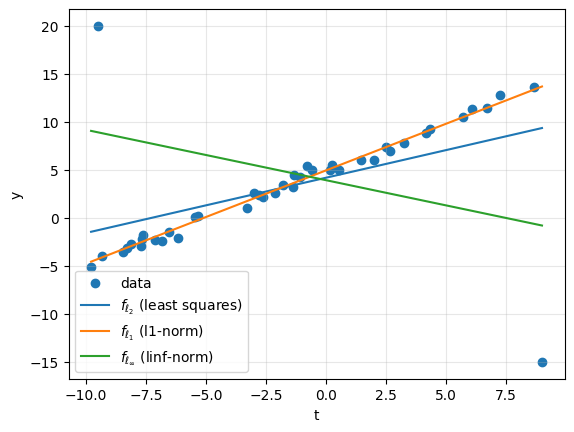

In [20]:
import numpy as np
import matplotlib.pyplot as plt

idx = np.argsort(t)
ts = t[idx]
ys = y[idx]

f_l2   = alpha_ls   + beta_ls   * ts
f_l1   = alpha_l1   + beta_l1   * ts
f_linf = alpha_linf + beta_linf * ts

plt.figure()
plt.scatter(t, y, marker='o', label='data')

plt.plot(ts, f_l2,   label=r'$f_{\ell_2}$ (least squares)')
plt.plot(ts, f_l1,   label=r'$f_{\ell_1}$ (l1-norm)')
plt.plot(ts, f_linf, label=r'$f_{\ell_\infty}$ (linf-norm)')

plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

it looks like L1-norm approximation fits the data best (most robust to the 2 clear outliers). least squares does a decent job, fitting the general trend of the data, but taking into some account the outliers. linf-norm does not fit the data well at all. it minimizes the worst residual, meaning the outliers have a large effect on the its function f.  

# Q2 Linear programs with absolute values (30 pts) {-}

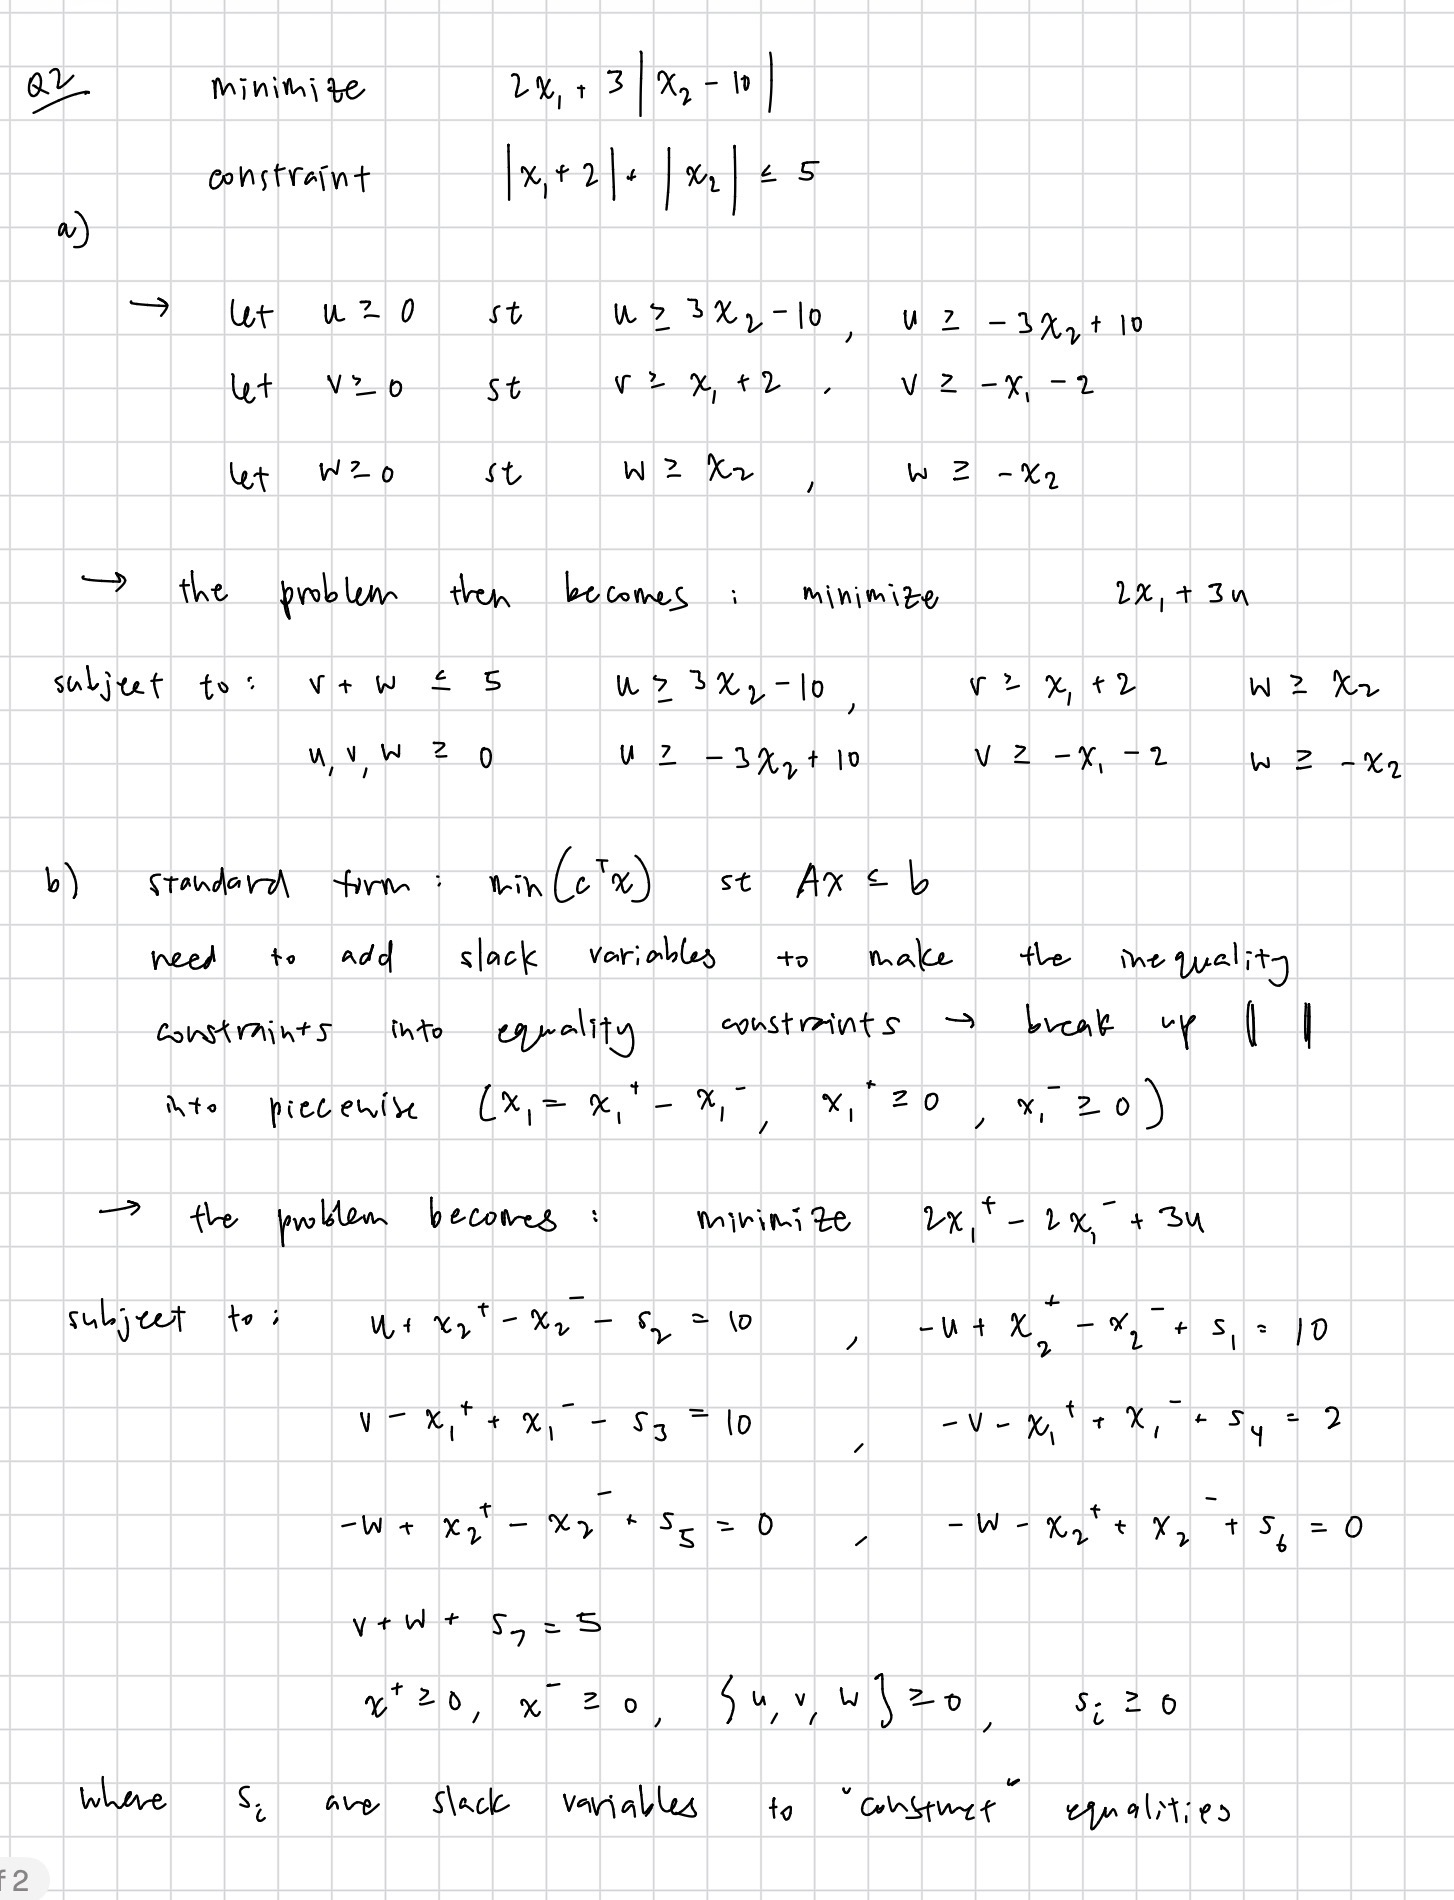

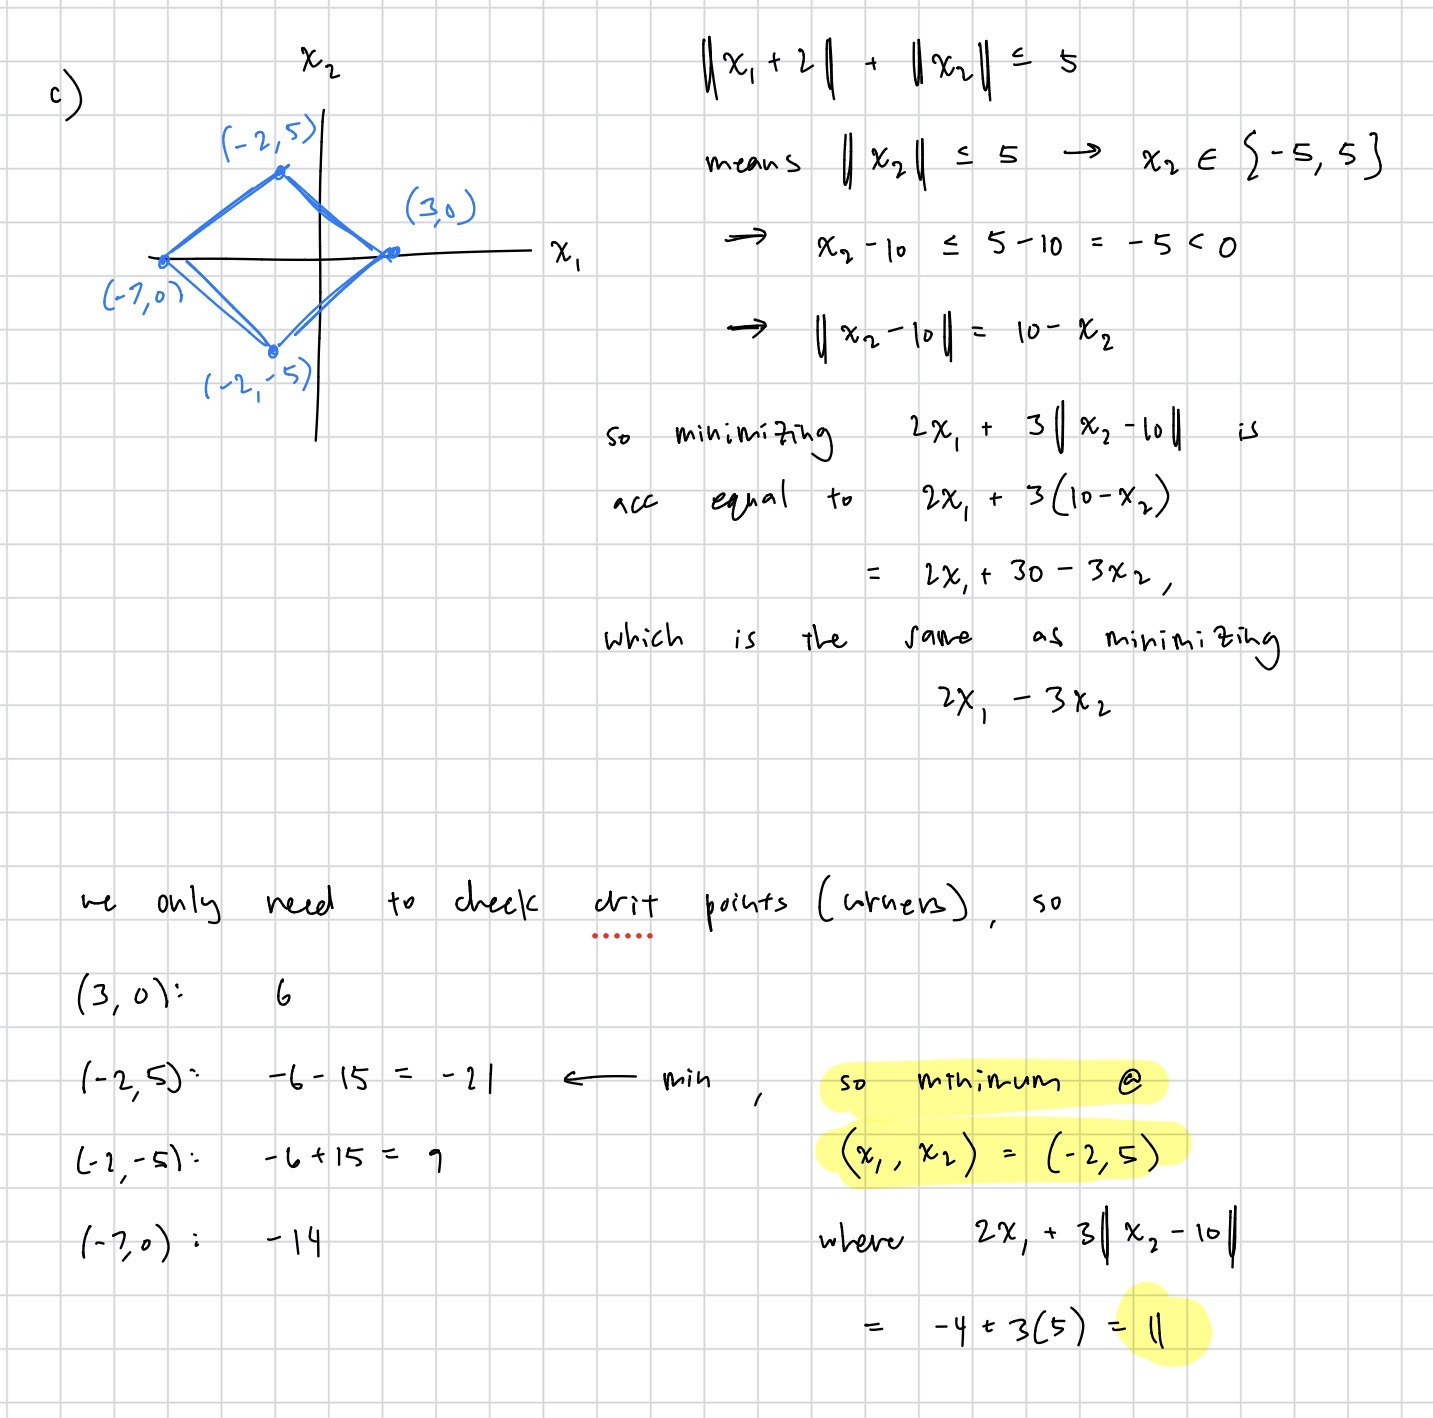

In [36]:
from IPython.display import Image, display

display(Image("2a,b.jpg", width=600), Image("2c.jpg", width=600))

# Q3 Optimal Illumination (40 pts) {-}

We consider an illumination system of m lamps, at positions $l_1, . . . , l_m \in {\mathbf{R}}^2$
, illuminating n flat patches.

![image.png](image.png)

The patches are line segments; the ith patch is given by $[v_i
, v_{i+1}]$ where $v_1, \dots , v_{n+1} \in \mathbf{R}^2$. The variables in the problem are the lamp powers $p_1, \dots , p_m$, which can vary between 0 and 1. The illumination at (the midpoint of) patch $i$ is denoted $I_i$. We will use a simple model for the illumination:

$$ I_i = \sum_{j=1}^m a_{ij} p_j, \qquad a_{ij} = r_{ij}^{-2} \max\{\cos \theta_{ij},0 \},$$

where $r_{ij}$ denotes the distance between lamp $j$ and the midpoint of patch $i$, and $θ_{ij}$ denotes the angle between the upward normal of patch $i$ and the vector from the midpoint of patch $i$ to lamp $j$, as shown in the figure. This model takes into account “self-shading” (*i.e.*, the fact that a patch is illuminated only by lamps in the halfspace it faces) but not shading of
one patch caused by another. Of course we could use a more complex illumination model, including shading and even reflections. This just changes the matrix relating the lamp powers to the patch illumination levels.

The problem is to determine lamp powers that make the illumination levels close to a given desired illumination level $I_{\rm des}$, subject to the power limits $0 \le p_i \le 1$.

(a) (10 pts) Suppose we use the maximum deviation $$\phi(p) = \max_{k=1,\dots,n} \lvert I_k - I_{\rm des}\rvert$$ as a measure for the deviation from the desired illumination level. Formulate the illumination problem using this criterion as a linear optimization problem.

(b) (20 pts) There are several suboptimal approaches based on weighted least-squares. You are given $A$ (where the entries of $A$ are $a_{ij}$ in the model for illumination) and $I_{\rm des}$. Import the file `HW4Q3.csv` using the following lines of code, you might have to change `HW4Q3.csv` to the corresponding filepath on your machine/Google Drive

In [3]:
# A_pd = pd.read_csv('/content/drive/MyDrive/HW4Q3.csv', header=None)
A_pd = pd.read_csv('HW4Q3.csv', header=None)
A = A_pd.to_numpy()
I_des = 2

We consider two examples.

1. *Saturated least-squares.* We can solve the least-squares problem
$$ \mbox{minimize}\quad \sum_{k=1}^n (I_k − I_{\rm des})^2$$ 

ignoring the constraints. If the solution is not feasible, we saturate it, *i.e.*, set $p_j = 0$ if $p_j \le 0$ and $p_j = 1$ if $p_j \ge 1$. Compute a feasible $p$ using this first method, and calculate $\phi(p)$.

2. *Weighted least-squares.* We consider another least-squares problem:
$$ \mbox{minimize}\quad  \sum_{k=1}^n (I_k − I_{\rm des})^2 + \mu \sum_{i=1}^m (p_i - 0.5)^2,$$ 

where $\mu \ge 0$ is used to attach a cost to a deviation of the powers from the value 0.5, which lies in the middle of the power limits. For large enough $\mu$, the solution of this problem will satisfy $0 \le p_i \le 1$, *i.e.*, be feasible for the original problem. Again, using the same $A$ and $I_{\rm des}$, find the smallest $\mu$ such that $p$ becomes feasible, and evaluate $\phi(p)$.

(c) (10 pts) Using the same data as in part (b), solve the LP you derived in part (a). Compare the solution with the solutions you obtained using the (weighted) least-squares methods of part (b).
